<a href="https://colab.research.google.com/github/CharlizeCo/house_prices_csc481_project/blob/main/house_price_prediction_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##NOTE: Save IPYNB to the GitHub (link below) so changes can be viewed and updated. (Colab files doesn't update in real time unlike google docs)

(Link: https://github.com/CharlizeCo/house_prices_csc481_project/tree/main)

###How to update file to GitHub:

**Before saving this to GitHub, save it like regular and then...**

**First go to file and select "Save a copy in GitHub"**

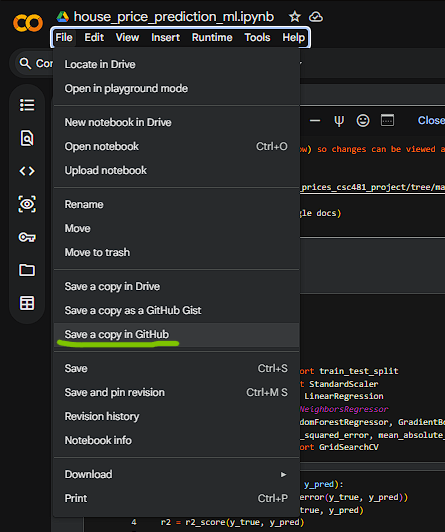

**Then select the specfic repo and have it save on the main branch. The new copy should replace the old file and show the updated changes**

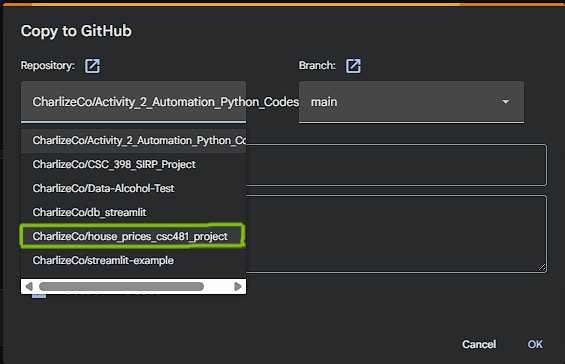

**Then select OK and it should redirect you to the GitHub Repo**

###Requirements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
#from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R^2 : {r2:.3f}")

###Dataset

In [3]:
house_url = "https://raw.githubusercontent.com/CharlizeCo/house_prices_csc481_project/refs/heads/main/House%20Price%20Prediction%20Dataset.csv"
house_df = pd.read_csv(house_url)
house_df.head(20)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [4]:
list(house_df.columns)

['Id',
 'Area',
 'Bedrooms',
 'Bathrooms',
 'Floors',
 'YearBuilt',
 'Location',
 'Condition',
 'Garage',
 'Price']

In [5]:
print(house_df.describe())

                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  999656.000000  


In [6]:
# set up features and target
features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
]

target = "Price"

X = house_df[features]
y = house_df[target]

# check for missing values
print(house_df.isnull().sum())

# remove duplicates if needed
df_fitbit = house_df.drop_duplicates()

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# view the split data
#print(f"{X_train}\n{X_test}\n{y_train}\n{y_test}")

# for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


###MODEL SECTION (inital results)
---

**First Model**

In [7]:
# first model (Linear Regression)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

**Second Model**

In [8]:
# second model (Random Forest)
rf = RandomForestRegressor(n_estimators=100) #model
rf.fit(X_train, y_train) #fit data
rf_pred = rf.predict(X_test) #predict data

**Third Model**

In [9]:
# third model (XGBoost)
xgb = GradientBoostingRegressor(n_estimators=100)
xgb.fit(X_train, y_train) #fit data
xgb_pred = xgb.predict(X_test) #predict data

**Evaluate Models**

In [10]:
evaluate_model("Linear Regression", y_test, lr_pred)
print("---")
evaluate_model("Random Forest Regression", y_test, rf_pred)
print("---")
evaluate_model("Gradient Boost Regression", y_test, xgb_pred)


Linear Regression
RMSE: 280695.07
MAE : 244587.20
R^2 : -0.013
---

Random Forest Regression
RMSE: 292442.18
MAE : 253085.47
R^2 : -0.099
---

Gradient Boost Regression
RMSE: 284113.44
MAE : 246105.59
R^2 : -0.038


**Graphs of Inital Results**

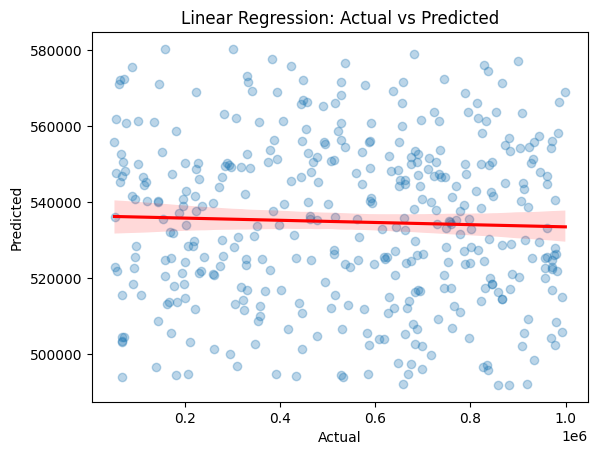

In [11]:
sns.regplot(x = y_test, y = lr_pred,
            line_kws={"color": "red"},
            scatter_kws={"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

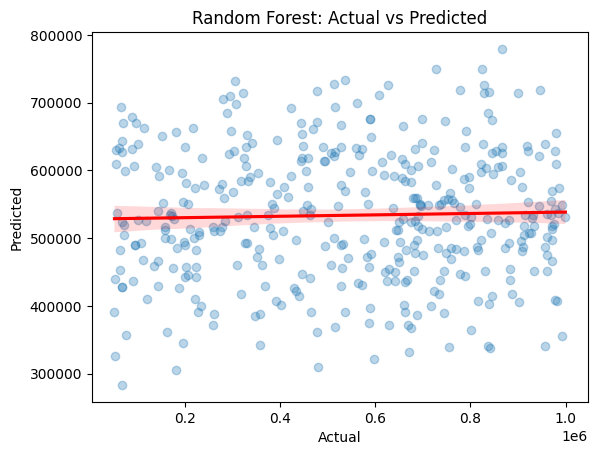

In [12]:
sns.regplot(x = y_test, y = rf_pred,
            line_kws={"color": "red"},
            scatter_kws={"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

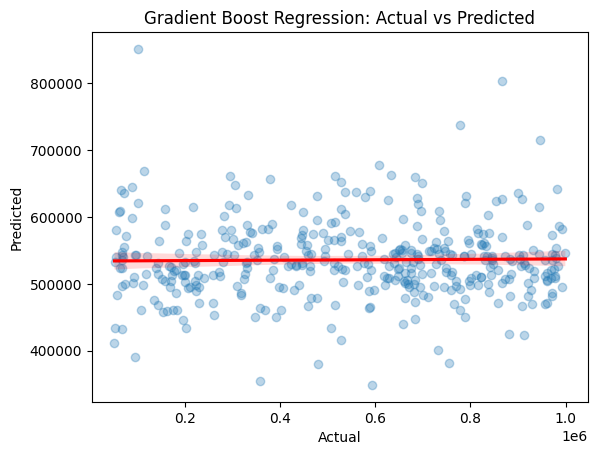

In [13]:
sns.regplot(x = y_test, y = xgb_pred,
            line_kws={"color": "red"},
            scatter_kws={"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boost Regression: Actual vs Predicted")
plt.show()

###IMPROVE MODELS
---

Identify important features and combine features in accordance

In [14]:
#from sklearn.ensemble import RandomForestClassifier
# random forest classification can help us find the feature importances by
# finding which model contributes the most to the model's accuracy
#clf = RandomForestClassifier(n_estimators=300)

#clf.fit(X_train, y_train) # fit data
#importances = clf.feature_importances_
# store feature importance into a dataset w/ feature
#feature_importance = pd.DataFrame({'Feature': features, "Importance": #importances}).sort_values('Importance', ascending = False) # sort
#print(feature_importance)

In [15]:
# time based feature combination
current_year = 2026
house_df['Age'] = current_year - house_df['YearBuilt']

# house feature ratios
house_df['Price_per_Sqft'] = house_df['Price'] / house_df['Area']
house_df['Area_per_Bedroom'] = house_df['Area'] / (house_df['Bedrooms'] + 1)
house_df['Area_per_Bathroom'] = house_df['Area'] / (house_df['Bathrooms'] + 1)
house_df['Room_to_Area_Ratio'] = (house_df['Bedrooms'] + house_df['Bathrooms']) / house_df['Area']

# category scores
condition_scores = {'Excellent': 4, 'Good': 3, 'Fair': 2, 'Poor': 1}
location_scores = {'Downtown': 4, 'Urban': 3, 'Suburban': 2, 'Rural': 1}

house_df['Condition_Score'] = house_df['Condition'].map(condition_scores)
house_df['Location_Score'] = house_df['Location'].map(location_scores)
house_df['Garage_Binary'] = (house_df['Garage'] == 'Yes').astype(int)
house_df.head(11)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Age,Price_per_Sqft,Area_per_Bedroom,Area_per_Bathroom,Room_to_Area_Ratio,Condition_Score,Location_Score,Garage_Binary
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919,56,110.234559,226.666667,272.000000,0.006618,4,4,0
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998,68,99.484551,712.000000,854.400000,0.002107,4,4,0
2,3,3592,2,2,3,1938,Downtown,Good,No,266746,88,74.261136,1197.333333,1197.333333,0.001114,3,4,0
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020,124,252.608696,193.200000,322.000000,0.006211,2,2,1
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056,51,129.122209,2463.000000,985.200000,0.001015,2,4,1
5,6,3944,1,2,1,1906,Urban,Poor,No,93262,120,23.646552,1972.000000,1314.666667,0.000761,1,3,0
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722,78,122.234269,1835.500000,1835.500000,0.000545,1,1,1
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893,101,173.996198,1139.666667,683.800000,0.001755,3,2,1
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878,94,1036.314286,210.000000,210.000000,0.006349,1,1,1
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375,26,155.778032,546.250000,546.250000,0.002746,1,4,0


In [16]:
# set up features and target
features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Age",
    "Price_per_Sqft",
    "Area_per_Bedroom",
    "Area_per_Bathroom",
    "Room_to_Area_Ratio",
    "Condition_Score",
    "Location_Score",
    "Garage_Binary"
]

target = "Price"

X = house_df[features]
y = house_df[target]

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# view the split data
#print(f"{X_train}\n{X_test}\n{y_train}\n{y_test}")

###MODELS

In [17]:
# first model (Linear Regression)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [18]:
# second model (Random Forest)
rf = RandomForestRegressor(n_estimators=100) #model
rf.fit(X_train, y_train) #fit data
rf_pred = rf.predict(X_test) #predict data

In [19]:
# third model (XGBoost)
xgb = GradientBoostingRegressor(n_estimators=100)
xgb.fit(X_train, y_train) #fit data
xgb_pred = xgb.predict(X_test) #predict data

**Evaluate**

In [20]:
evaluate_model("Linear Regression", y_test, lr_pred)
print("---")
evaluate_model("Random Forest Regression", y_test, rf_pred)
print("---")
evaluate_model("Gradient Boost Regression", y_test, xgb_pred)


Linear Regression
RMSE: 173520.06
MAE : 136312.87
R^2 : 0.613
---

Random Forest Regression
RMSE: 20825.38
MAE : 13423.13
R^2 : 0.994
---

Gradient Boost Regression
RMSE: 31187.78
MAE : 22968.18
R^2 : 0.987


**Graph of Models (Post Feature Fusion)**

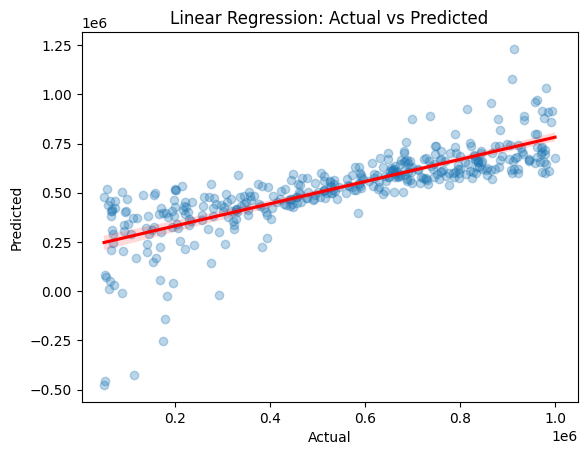

In [21]:
sns.regplot(x = y_test, y = lr_pred,
            line_kws={"color": "red"},
            scatter_kws={"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

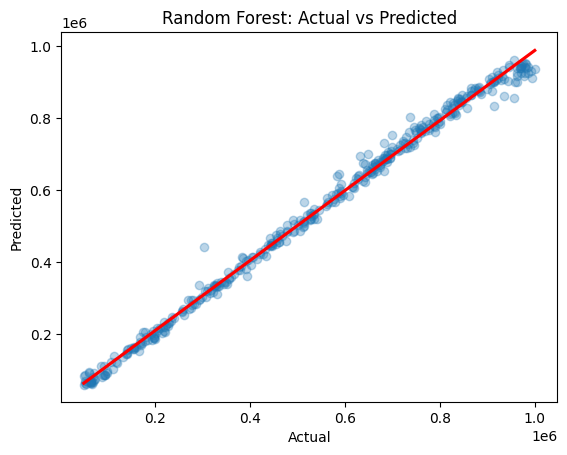

In [22]:
sns.regplot(x = y_test, y = rf_pred,
            line_kws={"color": "red"},
            scatter_kws={"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

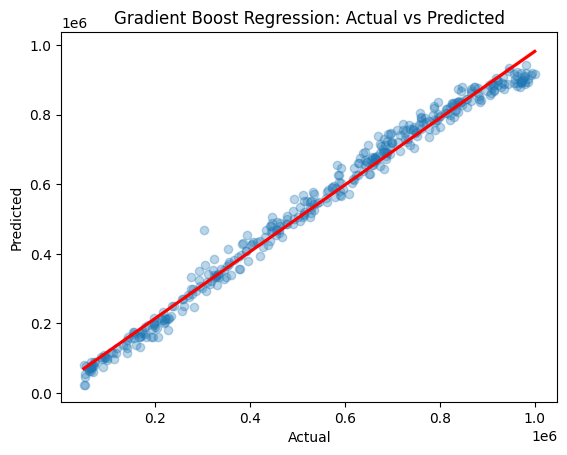

In [23]:
sns.regplot(x = y_test, y = xgb_pred,
            line_kws={"color": "red"},
            scatter_kws={"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boost Regression: Actual vs Predicted")
plt.show()

In [24]:
# Assuming X_train has ALL the engineered features
def predict_price_complete(area, bedrooms, bathrooms, floors, year_built,
                           location, condition, garage):

    # Create sample with ALL features your model expects
    sample = pd.DataFrame([{
        'Area': area,
        'Bedrooms': bedrooms,
        'Bathrooms': bathrooms,
        'Floors': floors,
        'YearBuilt': year_built,
        'Location': location,
        'Condition': condition,
        'Garage': garage,
        # Add engineered features (must match training)
        'Age': 2024 - year_built,
        'Area_per_Bedroom': area / (bedrooms + 1),
        'Area_per_Bathroom': area / (bathrooms + 1),
        'Bathroom_to_Bedroom': bathrooms / (bedrooms + 1),
        'Total_Rooms': bedrooms + bathrooms,
        'Room_Density': (bedrooms + bathrooms) / area,
        'Luxury_Index': (bathrooms / bedrooms) * floors,
        'Condition_Score': {'Excellent': 4, 'Good': 3, 'Fair': 2, 'Poor': 1}[condition],
        'Location_Score': {'Downtown': 4, 'Urban': 3, 'Suburban': 2, 'Rural': 1}[location],
        'Garage_Binary': 1 if garage == 'Yes' else 0,
        'Desirability_Score': 0,  # Calculate properly
        'Is_Luxury': 1 if (bathrooms >= 3 and area > 2000) else 0,
        'Is_New': 1 if (2024 - year_built <= 5) else 0,
        'Is_Old': 1 if (2024 - year_built >= 30) else 0,
        'Age_Squared': (2024 - year_built) ** 2,
        'Log_Age': np.log1p(2024 - year_built),
        'Area_Squared': area ** 2,
        'Age_Area_Interaction': (2024 - year_built) * area,
        'Is_Spacious': 1 if area > 1500 else 0,
        'Has_Enough_Bathrooms': 1 if bathrooms >= bedrooms * 0.75 else 0
    }])

    # Add one-hot encoded categorical columns if your model uses them
    # This depends on how you encoded Location, Condition, Garage

    # Make sure sample has EXACT same columns as X_train
    # Add missing columns with 0
    for col in X_train.columns:
        if col not in sample.columns:
            sample[col] = 0

    # Ensure same column order
    sample = sample[X_train.columns]

    # Predict (no scaling needed if your model doesn't use scaler in pipeline)
    price = rf.predict(sample)[0]
    return price

# Test
try:
    price = predict_price_complete(2485, 4, 2.5, 2, 1820, 'Suburban', 'Excellent', 'No')
    print(f"Predicted Price: ${price:,.2f}")
except Exception as e:
    print(f"Error: {e}")

Predicted Price: $59,001.96


**GridSearchCV**

In [25]:
# Linear Regression GridSearch Model

paramGrid = {
    'positive': [True, False],    # same output regardless of whether there are parameters or not
}

gridSearchLR = GridSearchCV(
    estimator = lr,
    param_grid = paramGrid,
    scoring = 'r2',   # trained on r2 due to historically producing highest scores w/ prev models
    cv = 5,
    verbose = 1,
    n_jobs = -1
)

# Train with housing csv data
gridSearchLR.fit(X_train, y_train)

print("Best Hyperparameters: \t", gridSearchLR.best_params_)    # Best parameter config for given model
print("Best Score: \t", gridSearchLR.best_score_)                 # Best cross-validation score

# Save best Linear Reg model produced by GridSearch
bestLR = gridSearchLR.best_estimator_
print("Best Linear Regression Model: ", bestLR)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Hyperparameters: 	 {'positive': False}
Best Score: 	 0.5782557852818023
Best Linear Regression Model:  LinearRegression()


In [26]:
# Random Forest GridSearch Model
paramGrid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10]
}

gridSearchRF = GridSearchCV(
    estimator = rf,
    param_grid = paramGrid,
    scoring = 'r2',   # otherwise, R-squared or mean absolute error (MAE)
    cv = 7,
    verbose = 1,
    n_jobs = -1
)

# Training with housing csv data
gridSearchRF.fit(X_train, y_train)

print("Best Hyperparameters", gridSearchRF.best_params_)    # Best parameter config for given model
print("Best Score", gridSearchRF.best_score_)                 # Best cross-validation score

# Save best Random Forest model produced by GridSearch
bestRF = gridSearchRF.best_estimator_
print("Best Random Forest Regression Model: ", bestRF)

Fitting 7 folds for each of 45 candidates, totalling 315 fits
Best Hyperparameters {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}
Best Score 0.9924637990447333
Best Random Forest Regression Model:  RandomForestRegressor(max_depth=30, n_estimators=300)


In [27]:
# Gradient Boost GridSearch Model
paramGrid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0]
}

gridSearchXGB = GridSearchCV(
    estimator = xgb,
    param_grid = paramGrid,
    scoring = 'r2',   # otherwise, R-squared or mean absolute error (MAE)
    cv = 5,
    verbose = 1,
    n_jobs = -1
)

# Training with housing csv data
gridSearchXGB.fit(X_train, y_train)

print("Best Hyperparameters", gridSearchXGB.best_params_)    # Best parameter config for given model
print("Best Score", gridSearchXGB.best_score_)                 # Best cross-validation score

# Save best Random Forest model produced by GridSearch
bestXGB = gridSearchXGB.best_estimator_
print("Best Gradient Boost Regression Model: ", bestXGB)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Hyperparameters {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.6}
Best Score 0.996377463041467
Best Gradient Boost Regression Model:  GradientBoostingRegressor(learning_rate=0.05, max_depth=7, n_estimators=500,
                          subsample=0.6)


**Testing GridSearch models**

In [28]:
# [Add custom testing samples via predict_price_complete function and test using models & parameters from GridSearch]

bestLR.fit(X_train, y_train)
predictions_lr = bestLR.predict(X_test)
#print("Linear Regression Predictions: ", predictions_lr, "\n---")

In [29]:
bestRF.fit(X_train, y_train)
predictions_rf = bestRF.predict(X_test)
#print("Random Forest Predictions: ", predictions_rf, "\n---")

In [30]:
bestXGB.fit(X_train, y_train)
predictions_xgb = bestXGB.predict(X_test)
#print("XGBoost Predictions: ", predictions_xgb)

**Evaluate GridSearch models**

In [31]:
evaluate_model("Linear Regression", y_test, predictions_lr)
print("---")
evaluate_model("Random Forest Regression", y_test, predictions_rf)
print("---")
evaluate_model("Gradient Boost Regression", y_test, predictions_xgb)


Linear Regression
RMSE: 173520.06
MAE : 136312.87
R^2 : 0.613
---

Random Forest Regression
RMSE: 20006.41
MAE : 12776.07
R^2 : 0.995
---

Gradient Boost Regression
RMSE: 12345.70
MAE : 8527.37
R^2 : 0.998


**Graphs of Models (Post GridSearchCV)**

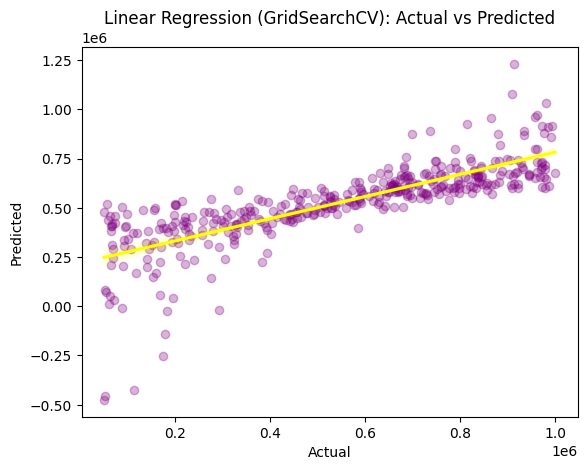

In [35]:
sns.regplot(x = y_test, y = predictions_lr, color="purple",
            line_kws = {"color": "yellow"},
            scatter_kws = {"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression (GridSearchCV): Actual vs Predicted")
plt.show()

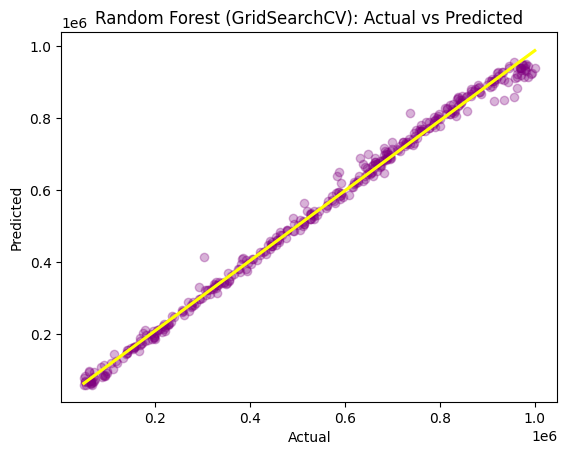

In [36]:
sns.regplot(x = y_test, y = predictions_rf, color="purple",
            line_kws = {"color": "yellow"},
            scatter_kws = {"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest (GridSearchCV): Actual vs Predicted")
plt.show()

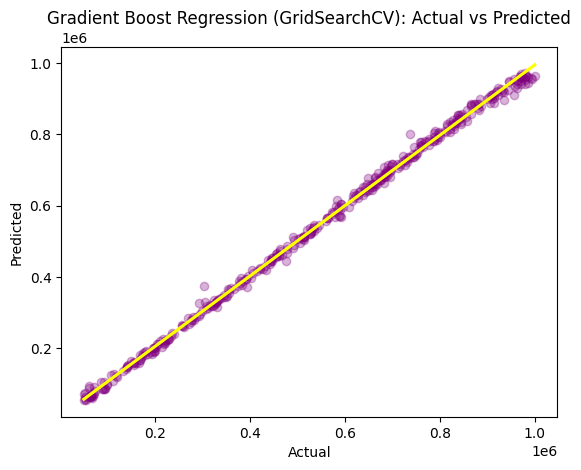

In [37]:
sns.regplot(x = y_test, y = predictions_xgb, color="purple",
            line_kws = {"color": "yellow"},
            scatter_kws = {"alpha" : 0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boost Regression (GridSearchCV): Actual vs Predicted")
plt.show()